## Consuming data using Kafka and Visualise (20%)
In this task, we will implement an Apache Kafka consumer to consume the data from Part 2.  
  
Important:   
-	In this part, Kafka consumers are used to consume the streaming data published from task 2.8.

#### Note:
Dear tutor, each plot requires a restart of the kernel. And only one plot can be run at a time. So please keep that in mind.<br>
<ul>
<li>For the plot for 6B, you need to run the task 1 code first and then the 6b plot code.</li>
<li>For the plot for 6C, you need to run the task 1 code first and then the 6c plot code.</li>
<li>For the plot(s) for Task 3, you need to run task 1 code first and then the code under the Task 3 heading and then the plot code (please restart the kernel for each of the plots).</li>
</ul>

In [1]:
from pyspark.sql import SparkSession

hostip = "kafka"

spark = SparkSession \
    .builder \
    .appName("A2B_Task3") \
    .getOrCreate()
spark.conf.set('spark.sql.session.timeZone', "Australia/Melbourne")

1.	Load the new meters CSV file into a data frame.

In [2]:
from pyspark.sql.types import StructType,StructField
from pyspark.sql.types import IntegerType, StringType, DecimalType, TimestampType

# Meters Table Schema
meters_schema = StructType([
    StructField("building_id", IntegerType(), True),
    StructField("meter_type", StringType(), True),
    StructField("ts", TimestampType(), True),
    StructField("value", DecimalType(10,4), True),
    StructField("row_id", IntegerType(), True)
])

meters_df = spark.read.csv("new_meters.csv", header=True, schema=meters_schema)
meters_df.show(1)

+-----------+----------+-------------------+------+------+
|building_id|meter_type|                 ts| value|row_id|
+-----------+----------+-------------------+------+------+
|        163|         c|2022-01-01 00:00:00|4.5719|     3|
+-----------+----------+-------------------+------+------+
only showing top 1 row



2.	Plot two diagrams to show data from 6b and 6c. You are free to choose the type of plot.

<IPython.core.display.Javascript object>


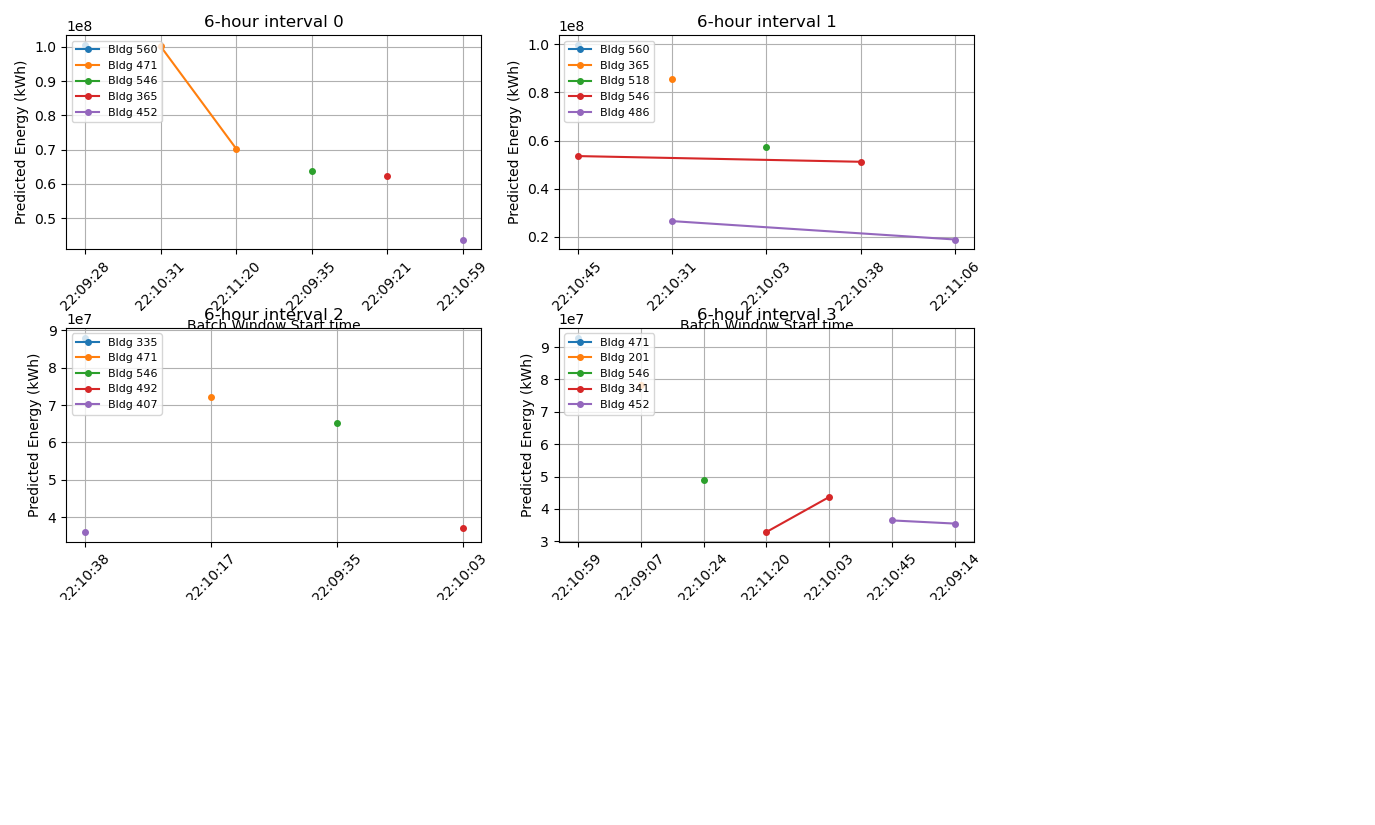

In [ ]:
%matplotlib notebook 
#6B

from kafka3 import KafkaConsumer
import json
import matplotlib.pyplot as plt
from collections import defaultdict, deque
import numpy as np
import time

hostip = "kafka"
topic = "8b"
TOP_N = 5  # number of buildings to display per interval panel

def connect_kafka_consumer(topic="8b"):
    consumer = KafkaConsumer(
        topic,
        consumer_timeout_ms=60000,
        bootstrap_servers=[f"{hostip}:9092"],
        auto_offset_reset="earliest",
        enable_auto_commit=True,
        group_id=f"parquet-stream-consumer-{topic}",
        value_deserializer=lambda x: x.decode("utf-8")
    )
#     print(f"Connected to Kafka topic '{topic}' at {hostip}:9092")
    return consumer

# storage 
data = defaultdict(lambda: defaultdict(lambda: deque(maxlen=10)))  
# data[interval][building_id] = deque of (timestamp, energy)

# plotting setup
intervals = [0, 1, 2, 3]
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=False)
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.set_title(f"6-hour interval {i}")
    ax.set_xlabel("Simulated Time / Batch")
    ax.set_ylabel("Predicted Energy (kWh)")
    ax.grid(True)

fig.tight_layout()
fig.canvas.draw()

# real-time update loop 
def consume_and_plot(consumer):
#     print("Listening for Kafka messages...\n")

    msg_count = 0
    for msg in consumer:
        msg_count += 1
        try:
            record = json.loads(msg.value)
            bldg = record["building_id"]
            interval = record["interval"]
            energy = float(record['6hr_building_NRGy_total'])
            ts = record['window']['start'][11:19]  # use the window start as x-axis

            # store data
            data[interval][bldg].append((ts, energy))

        except Exception as e:
            print("Bad message:", msg.value, "|", e)
            continue

        # redraw immediately upon new message
        for i, ax in enumerate(axes):
            ax.clear()
            ax.set_title(f"6-hour interval {i}")
            ax.set_xlabel("Batch Window Start time")
            ax.set_ylabel("Predicted Energy (kWh)")
            ax.tick_params(axis='x', labelrotation=45)

            # top N buildings for this interval
            all_bldgs = list(data[i].keys())
            latest_vals = {b: data[i][b][-1][1] for b in all_bldgs if len(data[i][b]) > 0}
            top_bldgs = sorted(latest_vals, key=latest_vals.get, reverse=True)[:TOP_N]

            for b in top_bldgs:
                times, energies = zip(*data[i][b])
                ax.plot(times, energies, marker='o', markersize=4, alpha=1, label=f"Bldg {b}")

            if top_bldgs:
                ax.legend(fontsize=8, loc="upper left")

            ax.grid(True)

        fig.canvas.draw()
        plt.pause(0.1)  # let UI refresh

consumer = connect_kafka_consumer()
consume_and_plot(consumer)

<IPython.core.display.Javascript object>


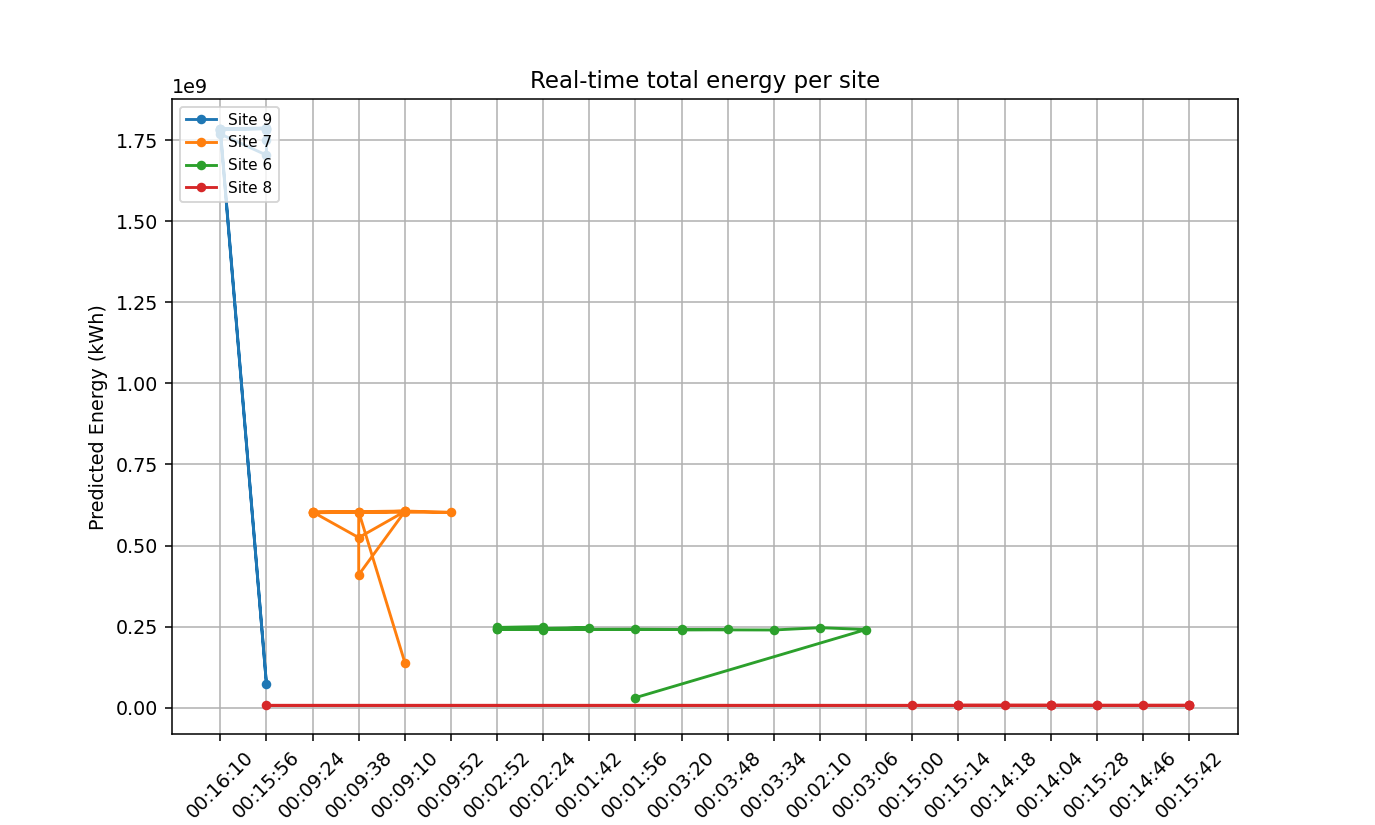

In [2]:
%matplotlib notebook 
#6C

from kafka3 import KafkaConsumer
import json
import matplotlib.pyplot as plt
from collections import defaultdict, deque
import numpy as np
import time

hostip = "kafka"
topic = "8c"
TOP_N = 5  # number of sites to display in the plot

def connect_kafka_consumer(topic="8c"):
    consumer = KafkaConsumer(
        topic,
        consumer_timeout_ms=60000,
        bootstrap_servers=[f"{hostip}:9092"],
        auto_offset_reset="earliest",
        enable_auto_commit=True,
        group_id=f"parquet-stream-consumer-{topic}",
        value_deserializer=lambda x: x.decode("utf-8")
    )
#     print(f"Connected to Kafka topic '{topic}' at {hostip}:9092")
    return consumer

# storage 
data = defaultdict(lambda: deque(maxlen=15)) #15 batches stored.
# structure: data[site_id] = deque of (ts, energy)

# plotting setup
fig, ax = plt.subplots(figsize=(10,6))
ax.set_title("Real-time total energy per site")
ax.set_xlabel("Window Start Time")
ax.set_ylabel("Predicted Energy (kWh)")
ax.grid(True)

# real-time update loop 
def consume_and_plot(consumer):
#     print("Listening for Kafka messages...\n")

    for msg in consumer:
        try:
            record = json.loads(msg.value)
            site = record["site_id"]
            energy = float(record["daily_site_NRGy_total"])  # or your appropriate field
            ts = record["window"]["start"][11:19]

            # store data
            data[site].append((ts, energy))

        except Exception as e:
            print("Bad message:", msg.value, "|", e)
            continue

        # redraw plot immediately per message
        ax.clear()
        ax.set_title("Real-time total energy per site")
        ax.set_xlabel("Window Start Time")
        ax.set_ylabel("Predicted Energy (kWh)")
        ax.tick_params(axis='x', labelrotation=45)
        ax.grid(True)

        # determine top N sites by latest energy
        latest_vals = {s: data[s][-1][1] for s in data if len(data[s]) > 0}
        top_sites = sorted(latest_vals, key=latest_vals.get, reverse=True)[:TOP_N]

        for s in top_sites:
            times, energies = zip(*data[s])
            ax.plot(times, energies, marker='o', markersize=4, alpha=1, label=f"Site {s}")

        if top_sites:
            ax.legend(fontsize=8, loc="upper left")

        fig.canvas.draw()
        plt.pause(0.1)

consumer = connect_kafka_consumer()
consume_and_plot(consumer)

3.	Plot a diagram to visualise the daily shortfall/excess energy in each site. The shortfall/excess energy is defined as the predicted total sum of energy in each site, minus the metered data (the value can be positive or negative, depending on the model and data quality).

In [3]:
from pyspark.sql import functions as F

# We need to load buildings data for the site_ids
buildings_info_schema = StructType([
    StructField("site_id", IntegerType(), True),
    StructField("building_id", IntegerType(), True),
    StructField("primary_use", StringType(), True),
    StructField("square_feet", IntegerType(), True),
    StructField("floor_count", IntegerType(), True),
    StructField("row_id", IntegerType(), True),
    StructField("year_built", IntegerType(), True),
    StructField("latent_y", DecimalType(10,2), True),
    StructField("latent_s", DecimalType(11,8), True),
    StructField("latent_r", DecimalType(10,2), True)
])

buildings_df = spark.read.csv("new_building_information.csv", header=True, schema=buildings_info_schema)

# Find out which building is in which site.
site_building_df = buildings_df.select("site_id", "building_id").distinct()

# Necessary transformation on meters_df - Add site_ids.
meters_with_site_df = meters_df.join(
    F.broadcast(site_building_df),
    on="building_id",
    how="left"
)

# Add date to the df
meters_with_site_df = meters_with_site_df.withColumn("date", F.to_date(F.col("ts")))

# Final required df -- finding daily aggregated totals for each site.
site_agg_df_real = meters_with_site_df \
    .groupBy("site_id", "date") \
    .agg(F.sum("value").alias("daily_site_total_real"))
site_agg_df_real.show(1)

# Store the real/target values for consumption in dict for easy query.
real_values = {
    (row["site_id"], str(row["date"])): float(row["daily_site_total_real"])
    for row in site_agg_df_real.collect()
}

+-------+----------+---------------------+
|site_id|      date|daily_site_total_real|
+-------+----------+---------------------+
|     13|2022-02-04|         5254238.9123|
+-------+----------+---------------------+
only showing top 1 row



##### Note:
Dear tutor, given below are Three plots.<br>
<ul>
    <li>A real-time bar chart/plot which shows the shortfall(green)/excess(red) for  all sites in one plot.
        <ul>
            <li>
                This plot is much faster at processing the stream data as it comes in.
            </li>
        </ul>
    </li>
    <li>A real-time multi-line plot which shows the real and predicted values as two lines on one sub-plot<ul><li>Each sub-plot is for each site_id and so there are 16 sub-plots.</li></ul></li>
    <li>A real-time bar chart/plot which shows the shortfall(green)/excess(red) on one sub-plot<ul><li>Each sub-plot is for each site_id and so there are 16 sub-plots.</li></ul></li>
</ul>

<IPython.core.display.Javascript object>


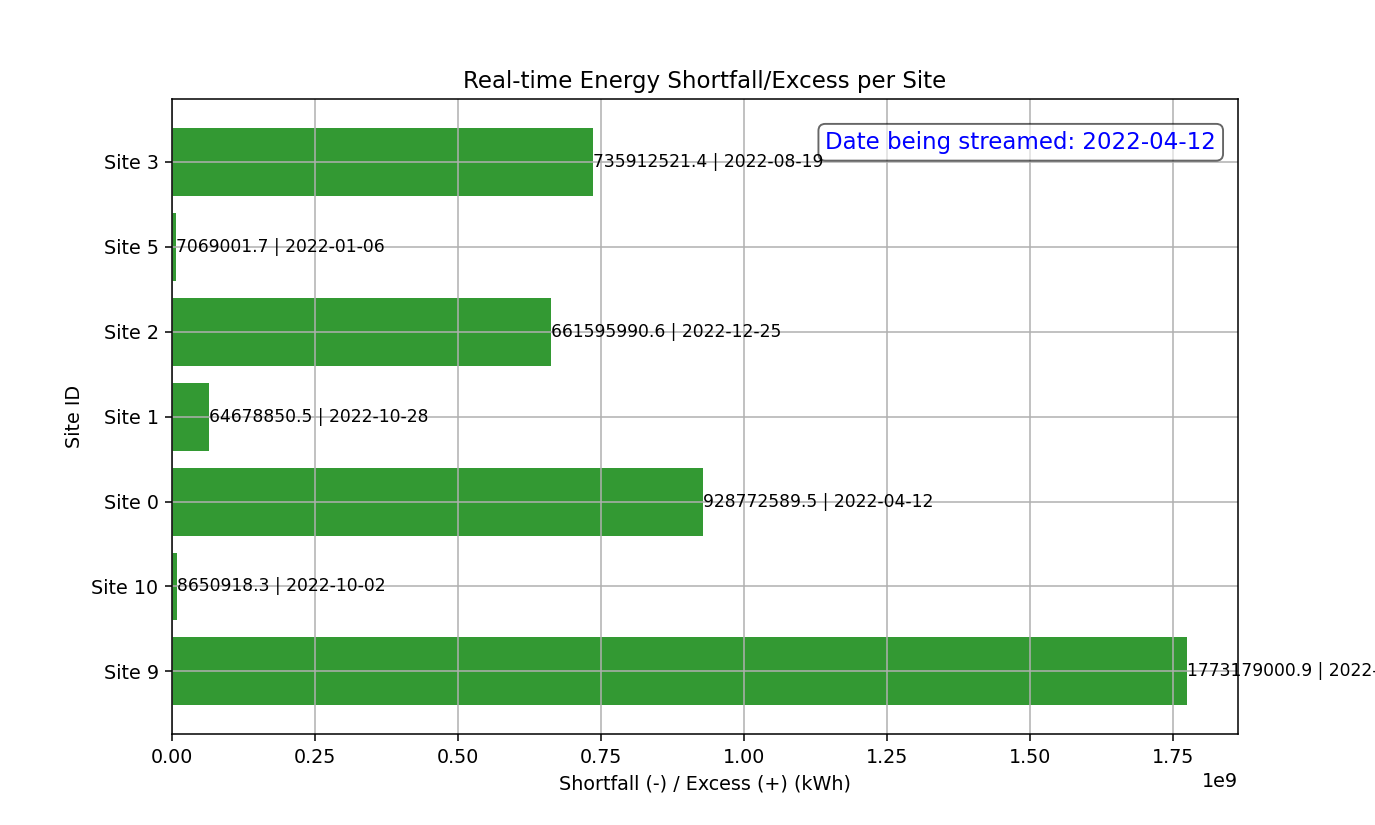

In [ ]:
%matplotlib notebook
import json
from kafka3 import KafkaConsumer
import matplotlib.pyplot as plt
from collections import deque
import numpy as np

# Kafka config
hostip = "kafka"
topic = "8c"
def connect_kafka_consumer():
    consumer = KafkaConsumer(
        topic,
        bootstrap_servers=[f"{hostip}:9092"],
        auto_offset_reset="latest",
        enable_auto_commit=True,
        group_id=f"shortfall-excess-consumer",
        value_deserializer=lambda x: x.decode("utf-8")
    )
    return consumer
consumer = connect_kafka_consumer()

MAX_POINTS = 16  # limit rolling memory per site
shortfall_data = {}  # {site_id: deque([(timestamp, shortfall)])}

# Matplotlib config
fig, ax = plt.subplots(figsize=(10, 6))
plt.ion()
ax.set_title("Real-time Energy Shortfall/Excess per Site")
ax.set_xlabel("Shortfall (-) / Excess (+)")
ax.set_ylabel("Site ID")
ax.grid(True)

def consume_and_plot(consumer):
    for msg in consumer:
        try:
            record = json.loads(msg.value)
            site = record["site_id"]
            ts = record["window"]["start"][11:19]
            pred = float(record["daily_site_NRGy_total"])
            date = str(record["date"])

            real_val = real_values.get((site, date), None)
            if real_val is None:
                # skip unknown site/date combos
                continue

            shortfall = pred - real_val

            if site not in shortfall_data:
                shortfall_data[site] = deque(maxlen=MAX_POINTS)
            shortfall_data[site].append((ts, shortfall, date))

        except Exception as e:
            print("Bad message:", msg.value, "|", e)
            continue

        # Prepare data for plotting
        sites = list(shortfall_data.keys())
        latest_points = [shortfall_data[s][-1] for s in sites]  # (ts, shortfall, date)
        latest_vals = [pt[1] for pt in latest_points]
        latest_dates = [pt[2] for pt in latest_points]


        ax.clear()
        ax.set_title("Real-time Energy Shortfall/Excess per Site")
        ax.set_xlabel("Shortfall (-) / Excess (+) (kWh)")
        ax.set_ylabel("Site ID")
        ax.grid(True)

        colors = ["green" if val >= 0 else "red" for val in latest_vals]
        y_positions = np.arange(len(sites))

        ax.barh(y_positions, latest_vals, color=colors, alpha=0.8)
        ax.set_yticks(y_positions)
        ax.set_yticklabels([f"Site {s}" for s in sites])
        # Add a dynamic date label (top-right corner)
        ax.text(
            0.98, 0.95,
            f"Date being streamed: {date}",
            transform=ax.transAxes,
            fontsize=12,
            color="blue",
            ha="right",
            va="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.6)
        )

        # Annotate values
        for i, (val, d) in enumerate(zip(latest_vals, latest_dates)):
            ax.text(
                val,
                i,
                f"{val:.1f} | {d}",
                va="center",
                ha="left" if val > 0 else "right",
                fontsize=9
            )


        fig.canvas.draw()
        plt.pause(0.1)

consume_and_plot(consumer)

<IPython.core.display.Javascript object>


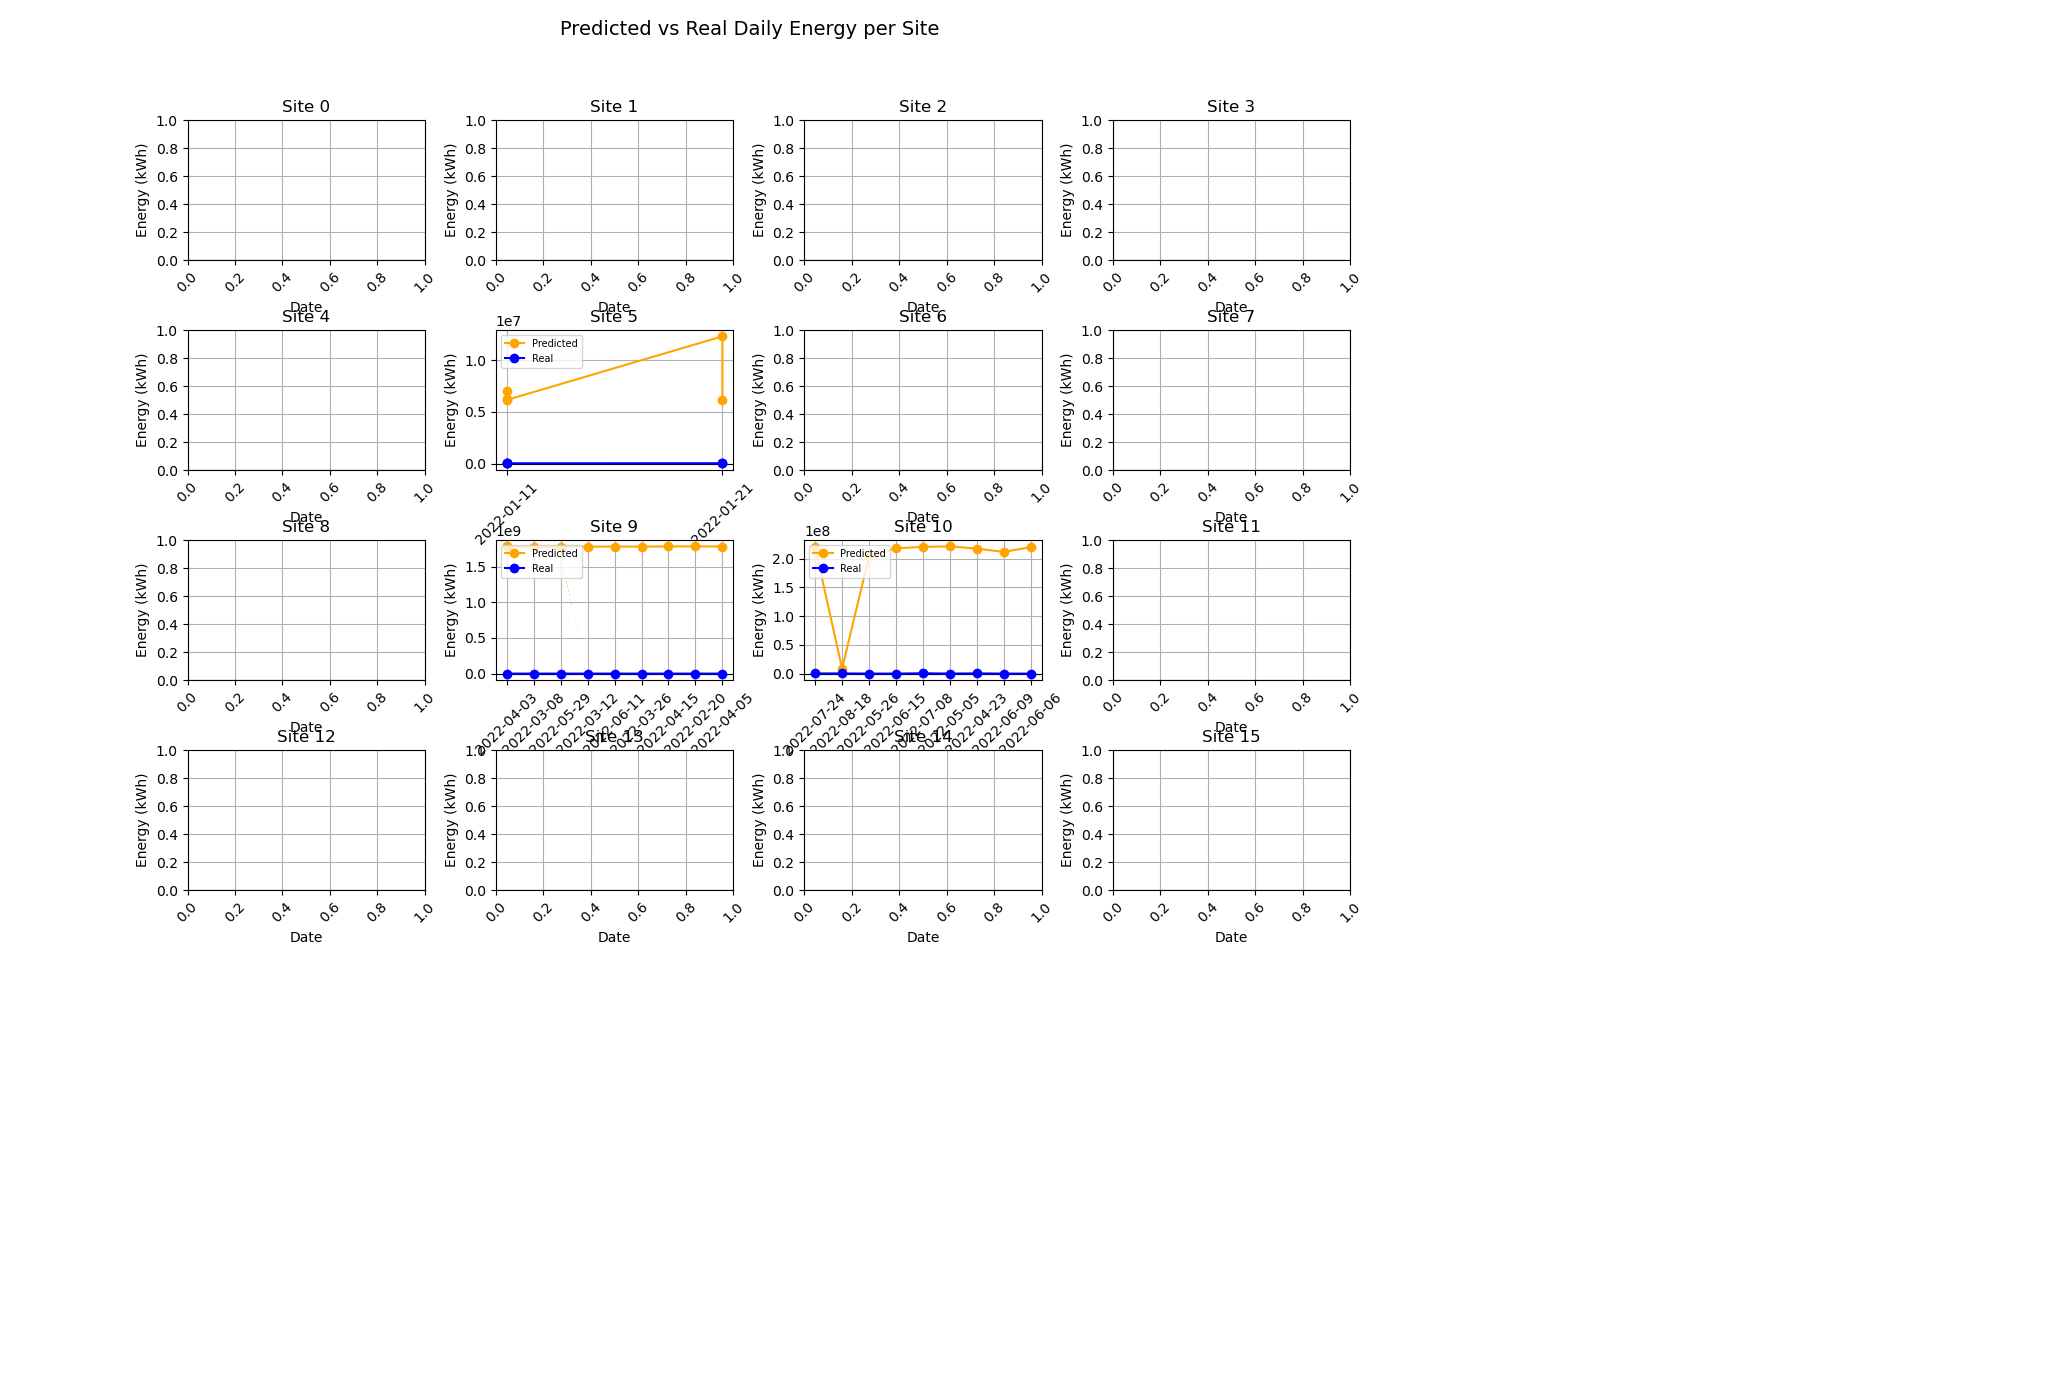

Heartbeat poll expired, leaving group
Node 1 connection failed -- refreshing metadata
Marking the coordinator dead (node coordinator-1) for group parquet-stream-consumer-8c: Node Disconnected.
Marking the coordinator dead (node coordinator-1) for group parquet-stream-consumer-8c: Node Disconnected.


In [ ]:
%matplotlib notebook
import json
from kafka3 import KafkaConsumer
import matplotlib.pyplot as plt
from collections import deque, defaultdict
import numpy as np

# Kafka config
hostip = "kafka"
topic = "8c"
MAX_POINTS = 9
TOP_N = 16  # since there are 16 sites

# connect Kafka
def connect_kafka_consumer(topic="8c"):
    consumer = KafkaConsumer(
        topic,
        consumer_timeout_ms=60000,
        bootstrap_servers=[f"{hostip}:9092"],
        auto_offset_reset="latest",
        enable_auto_commit=True,
        group_id=f"parquet-stream-consumer-{topic}",
        value_deserializer=lambda x: x.decode("utf-8")
    )
    return consumer

consumer = connect_kafka_consumer()

# storage for streaming values
real_data = defaultdict(lambda: deque(maxlen=MAX_POINTS))
pred_data = defaultdict(lambda: deque(maxlen=MAX_POINTS))

unique_sites = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
# num_sites = 16

# --- Plot setup (4x4 grid) ---
cols = 4
rows = 4

fig, axes = plt.subplots(rows, cols, figsize=(15, 10), sharex=False)
axes = axes.flatten()

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.ion()
fig.suptitle("Predicted vs Real Daily Energy per Site", fontsize=14)

# Initialize subplots
for i, site in enumerate(unique_sites):
    ax = axes[i]
    ax.set_title(f"Site {site}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Energy (kWh)")
    ax.grid(True)
    ax.axhline(0, color="black", lw=0.8)

# # Hide any unused axes (e.g. if fewer than 16 sites)
# for j in range(len(unique_sites), len(axes)):
#     axes[j].axis("off")

# --- Consumer loop ---
def consume_and_plot(consumer):
    for msg in consumer:
        try:
            record = json.loads(msg.value)
            site = record["site_id"]
            date = str(record["date"])
            pred = float(record["daily_site_NRGy_total"])
            real_val = real_values.get((site, date), None)
            if real_val is None:
                continue

            pred_data[site].append((date, pred))
            real_data[site].append((date, real_val))

        except Exception as e:
            print("Bad message:", msg.value, "|", e)
            continue

        # Redraw plots
        for i, site in enumerate(unique_sites):
            ax = axes[i]
            ax.clear()
            ax.set_title(f"Site {site}")
            ax.set_xlabel("Date")
            ax.set_ylabel("Energy (kWh)")
            ax.grid(True)
            ax.axhline(0, color="black", lw=0.8)
            ax.tick_params(axis="x", labelrotation=45)

            # Plot predicted values
            if site in pred_data and len(pred_data[site]) > 0:
                dates_pred, preds = zip(*pred_data[site])
                ax.plot(dates_pred, preds, color="orange", marker="o", label="Predicted")

            # Plot real values
            if site in real_data and len(real_data[site]) > 0:
                dates_real, reals = zip(*real_data[site])
                ax.plot(dates_real, reals, color="blue", marker="o", label="Real")

            # Only add the legend if there is data for either predicted or real
            if len(pred_data[site]) > 0 or len(real_data[site]) > 0:
                ax.legend(fontsize=7, loc="upper left")

                fig.canvas.draw()

consume_and_plot(consumer)

<IPython.core.display.Javascript object>


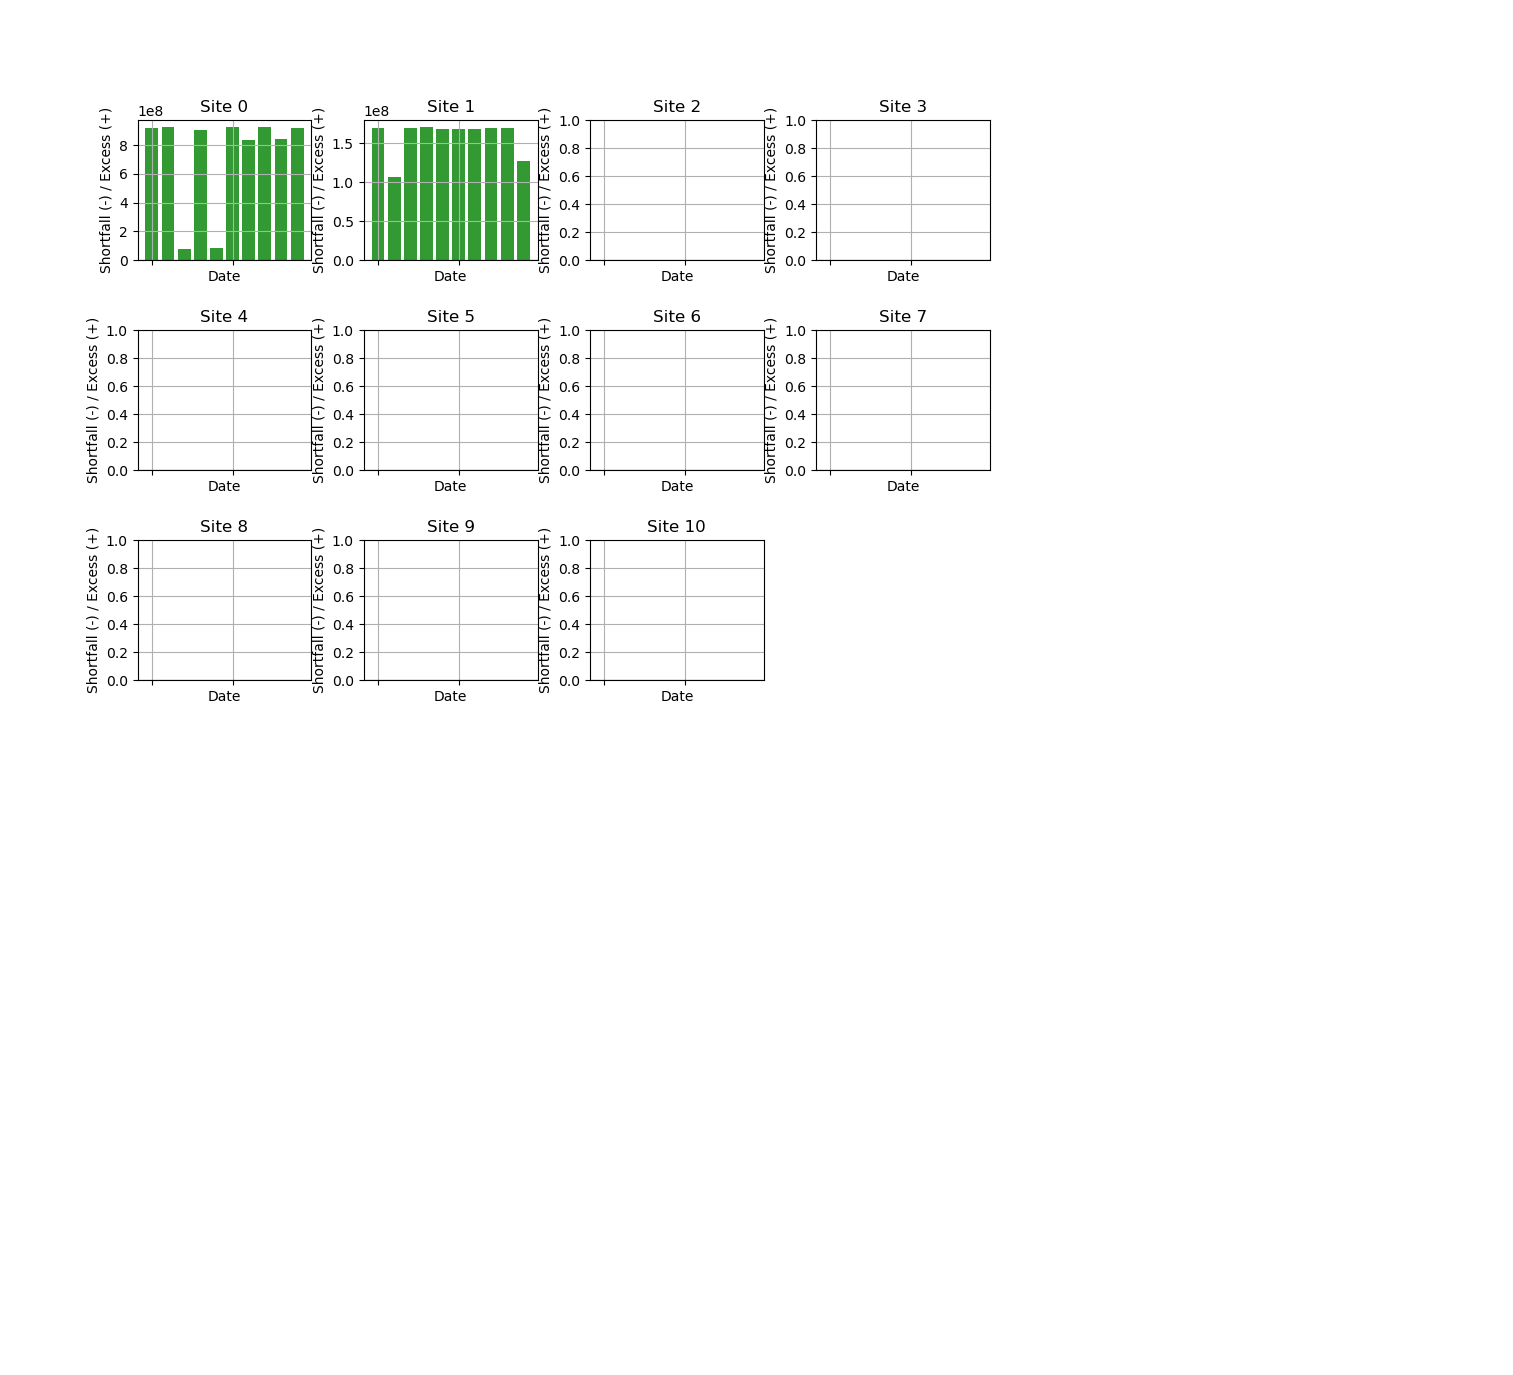

Heartbeat poll expired, leaving group


In [ ]:
%matplotlib notebook
import json
from kafka3 import KafkaConsumer
import matplotlib.pyplot as plt
from collections import defaultdict, deque
import numpy as np

# Kafka config
hostip = "kafka"
topic = "8c"
def connect_kafka_consumer():
    consumer = KafkaConsumer(
        topic,
        bootstrap_servers=[f"{hostip}:9092"],
        auto_offset_reset="latest",
        enable_auto_commit=True,
        group_id=f"shortfall-excess-consumer",
        value_deserializer=lambda x: x.decode("utf-8")
    )
    return consumer
consumer = connect_kafka_consumer()

MAX_POINTS = 10  # limit rolling memory per site
shortfall_data = {}  # {site_id: deque([(timestamp, shortfall)])}

# Plot Setup
unique_sites = sorted(set([row["site_id"] for row in site_agg_df_real.collect()]))
num_sites = len(unique_sites)

cols = 4
rows = int(np.ceil(num_sites / cols))

fig, axes = plt.subplots(rows, cols, figsize=(11, 10), sharex=True)
axes = axes.flatten()

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.ion()
fig.suptitle("Real-Time Daily Energy Shortfall/Excess per Site", fontsize=14)

for i, site in enumerate(unique_sites):
    ax = axes[i]
    ax.set_title(f"Site {site}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Shortfall (-) / Excess (+)")
    ax.axhline(0, color="black", lw=0.8)
    ax.grid(True)

def consume_and_plot(consumer):
    for msg in consumer:
        try:
            record = json.loads(msg.value)
            site = record["site_id"]
            ts = record["window"]["start"][11:19]
            pred = float(record["daily_site_NRGy_total"])
            date = str(record["date"])

            real_val = real_values.get((site, date), None)
            if real_val is None:
                continue

            shortfall = pred - real_val

            if site not in shortfall_data:
                shortfall_data[site] = deque(maxlen=MAX_POINTS)
            shortfall_data[site].append((ts, shortfall))

        except Exception as e:
            print("Bad message:", msg.value, "|", e)
            continue

        # Redraw each subplot
        for i, site in enumerate(unique_sites):
            ax = axes[i]
            ax.clear()
            ax.set_title(f"Site {site}")
            ax.set_xlabel("Date")
            ax.set_ylabel("Shortfall (-) / Excess (+)")
            ax.axhline(0, color="black", lw=0.8)
            ax.grid(True)

            if site in shortfall_data and len(shortfall_data[site]) > 0:
                dates, diffs = zip(*shortfall_data[site])
                colors = ["green" if val >= 0 else "red" for val in diffs]
                x = np.arange(len(dates))
                
                # Plotting the bar chart with dates on the x-axis
                ax.bar(x, diffs, color=colors, alpha=0.8)
                ax.set_xticks(x)
                ax.set_xticklabels(dates, rotation=45, ha="right")

        # Annotate the date in the top-right corner of the figure
        fig.text(
            0.98, 0.95,  # Position relative to the figure
            f"Date being streamed: {date}",
            transform=fig.transFigure,  # Use the figure coordinate system
            fontsize=12,
            color="blue",
            ha="right",
            va="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.6)  # Background box
        )

        fig.canvas.draw()
        plt.pause(0.1)

consume_and_plot(consumer)

### AI Statement

I used ChatGPT5o and ChatGPT5o-mini (https://chatgpt.com/) to understand how to do real-time plotting and working with parquet ingestion and casting the data for output streaming. I also used it to understand the code in the Lab files.